# **Maestría en Inteligencia Artificial Aplicada**

## Curso: **Procesamiento de Lenguaje Natural**

### Tecnológico de Monterrey

### Prof Luis Eduardo Falcón Morales

### **Actividad en Equipo - Semanas 4 y 5**

### **Vectores Embebidos de HuggingFace**

#### **Nombres y matrículas de los integrantes del equipo:**



*   A01797221 Jose Angel Barajas Flores
*   Elemento de lista



In [62]:
# Aquí deberán incluir todas las librerías que requieran durante esta actividad:

import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.

from IPython.display import Markdown
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login
from transformers import pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt




[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI llamados **amazon_cells_labelled.txt**, **imdb_labelled.txt** y   **yelp_labelled.txt**. Cada uno de estos archivos corresponden a comentarios de usuarios que adquirieron un celular a través de la plataforma de Amazon, de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMDb y sobre servicios de comida dejados en la plataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI cuya liga es la siguiente:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



# **Pregunta - 1:**



Descarga los 3 archivos de la plataforma de la UCI indicado previamente y genera un nuevo DataFrame de Pandas con ellos.

**Llama simplemente "df" a dicho DataFrame.**




In [2]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


dfa = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase4\amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase4\imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase4\yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

## Ahora sabemos que dfi tiene probelmas con unso campos


newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.

# leer archivo completo como texto
with open(r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase4\imdb_labelled.txt",
          "r",
          encoding="utf-8") as f:
    
    raw_text = f.read()

# encontrar TODOS los registros
records = re.findall(r'(.*?\t[01])(?:\n|$)', raw_text, re.DOTALL)

for rec in records:

    review, label = rec.rsplit('\t', 1)

    newdfi.append({
        "review": review.strip(),
        "label": int(label.strip())
    })

# convertir a dataframe
dfii = pd.DataFrame(newdfi, columns=['review','label'])

# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.
print()
print(r'Despues de arreglar IMDB')
print()
print(df.info())






# *********** Aquí termina la sección de agregar código *************


Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)

Despues de arreglar IMDB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB
None


In [3]:
# Verifiquemos la información del DataFrame:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [4]:
# Y mostremos sus primeros registros:

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [5]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

# **Pregunta - 2:**

Proceso de limpieza. Aplica el proceso de limpieza que consideres adecuado.











In [6]:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


#Funcion de limpieza 
def clean_tok(docs):

    # Expand negations
    docs = docs.replace("don't", "do not")
    docs = docs.replace("can't", "can not")
    docs = docs.replace("won't", "will not")

    # Keep only alphabetic chars
    text = re.sub(r'[^a-zA-ZáéíóúñÁÉÍÓÚÑ\s]', ' ', docs)

    # Lowercase + tokenize
    words = text.lower().split()

    # Remove very short words
    words = [w for w in words if len(w) > 1]

    # Remove stopwords
    words = [w for w in words if w not in mystopwords]

    return words

#Funcion Extra limpieza
def clean_doc(doc):

    tokens = []

    for word in doc:

        # 1. Lemmatization
        lemma = lemmatizer.lemmatize(word)

        # 2. Filtro adicional de longitud
        if len(lemma) > 1:
            tokens.append(lemma)
  
    return tokens


# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))
print()



 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.



# Aplicamos el proceso de limpieza y tokenización:
Xcleantok = [clean_tok(x) for x in X]

# Aplicamos el proceso de limpieza/normalización adicionales:
Xclean = [clean_doc(x) for x in Xcleantok]

# Desplegamos status actual
Xclean[0:10]    


# *********** Aquí termina la sección de agregar código *************

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158




[['no', 'way', 'plug', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem'],
 ['mic', 'great'],
 ['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume'],
 ['several',
  'dozen',
  'several',
  'hundred',
  'contact',
  'imagine',
  'fun',
  'sending',
  'one',
  'one'],
 ['razr', 'owner', 'must'],
 ['needless', 'say', 'wasted', 'money'],
 ['waste', 'money', 'time']]

In [7]:
# Despleguemos los primeros comentarios después de tu proceso de limpieza:

for x in Xclean[0:5]:
  print(x)


['no', 'way', 'plug', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem']
['mic', 'great']


# **Pregunta - 3:**



Realicemos una partición aleatoria con los porcentajes que consideres más adecuados. Utiliza una semilla para su reproducibilidad.

In [8]:

# ************* Inicia la sección de agregar código:*****************************

from sklearn.model_selection import train_test_split

Xtrain, Xval_and_test, ytrain, yval_and_test = train_test_split(Xclean, y, train_size=.60, shuffle=True, random_state=1,stratify=y)
Xval, Xtest, yval, ytest = train_test_split(Xval_and_test, yval_and_test, test_size=.50, shuffle=True, random_state=1,stratify=yval_and_test)

print('X,y Train:', len(Xtrain), len(ytrain))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))
print()
print('\nTrain distribution:')
print(ytrain.value_counts(normalize=True))
print()
print('\nValidation distribution:')
print(yval.value_counts(normalize=True))
print()
print('\nTest distribution:')
print(ytest.value_counts(normalize=True))
print()



# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(Xtrain), len(ytrain))
print('X,y Val:', len(Xval), len(yval))
print('X,y Test', len(Xtest), len(ytest))

X,y Train: 1800 1800
X,y Val: 600 600
X,y Test 600 600


Train distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


Validation distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


Test distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

X,y Train: 1800 1800
X,y Val: 600 600
X,y Test 600 600


# **Pregunta - 4:**




### **Construye tu vocabulario a continuación utilizando solamente el conjunto de Train:**


Construye tu vocabulario a continuación: 

a. Usa el conjunto de entrenamiento para generar tu vocabulario con un tamaño que consideres 
adecuado. Si lo deseas, puedes filtrar tu vocabulario por la frecuencia mínima de uso de cada 
palabra, así como por su longitud mínima en caracteres. 

b. Indica el tamaño del vocabulario obtenido. 

c. Con el vocabulario generado, filtra los conjuntos de entrenamiento, validación y prueba para que todos los comentarios usen solamente las palabras de este vocabulario. Llamar train_X, val_X y test_X a estos tres conjuntos.

Procedamos ahora con los vectores embebidos de cada palabra y comentario de modelos preentrenados, en lugar de los vectores generados con las matrices Tf-idf de la actividad de la semana pasada.

In [9]:
# a.	Usa el conjunto de entrenamiento para generar tu vocabulario
#     con un tamaño que consideres adecuado:


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

from collections import Counter

midiccionario = Counter()

for k in range(len(Xtrain)):
  midiccionario.update(Xtrain[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))
print(midiccionario.most_common()[:-11:-1])
print()




# *********** Aquí termina la sección de agregar código *************




Longitud del diccionario: 3355

(word,frequency):
[('not', 260), ('good', 144), ('movie', 134), ('great', 133), ('phone', 111), ('film', 101), ('one', 96), ('food', 81), ('like', 79), ('time', 75)]
[('nature', 1), ('exploration', 1), ('powerful', 1), ('restored', 1), ('prompted', 1), ('operates', 1), ('humanity', 1), ('argued', 1), ('scientist', 1), ('government', 1)]



In [10]:
# b.	Indica el tamaño del vocabulario generado.

print('Longitud del vocabulario generado:',len(midiccionario))
print()


# ******* Inicia la sección de agregar código: ***********


# Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo
# dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

# Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural
# (es decir, basadas en conteo) mayor o igual a "min_freq".

min_freq = 3

midicc = Counter({
    word: freq
    for word, freq in midiccionario.items()
    if freq >= min_freq
})


print('Nueva longitud del nuevo vocabulario filtrado por frecuencia',min_freq," : ", len(midicc))
print(midicc.most_common(10))
print(midicc.most_common()[:-11:-1])     # veamos algunos elementos del diccionario.



# *********** Aquí termina la sección de agregar código *************

Longitud del vocabulario generado: 3355

Nueva longitud del nuevo vocabulario filtrado por frecuencia 3  :  851
[('not', 260), ('good', 144), ('movie', 134), ('great', 133), ('phone', 111), ('film', 101), ('one', 96), ('food', 81), ('like', 79), ('time', 75)]
[('angel', 3), ('owned', 3), ('guest', 3), ('treat', 3), ('begin', 3), ('comment', 3), ('buying', 3), ('significant', 3), ('idea', 3), ('god', 3)]


In [11]:
# c.	Con el vocabulario generado, filtra los conjuntos de entrenamiento,
#     validación y prueba para que todos los comentarios usen solamente las
#     palabras de este vocabulario.

#     Llamar train_X, val_X y test_X a estos tres conjuntos.


# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


train_X = []
for ss in Xtrain:
  train_X.append([w for w in ss if w in midicc])

val_X = []
for ss in Xval:
  val_X.append([w for w in ss if w in midicc])

test_X = []
for ss in Xtest:
  test_X.append([w for w in ss if w in midicc])


# *********** Aquí termina la sección de agregar código *************


In [12]:
# Vemos el resultado de los primeros comentarios del conjunto de validación:

for ss in val_X[0:5]:
  print(ss)

['one', 'note', 'could', 'use']
['used', 'talk', 'hour', 'battery', 'would', 'literally']
['performance', 'simply']
['subtle', 'script', 'well', 'served', 'perfect', 'performance', 'though', 'perhaps', 'direction', 'time', 'character', 'often', 'mention']
['character', 'one', 'even', 'good', 'especially', 'bad']


# **Pregunta - 5:**

Incluye tus comentarios sobre cada modelo de HuggingFace indicado.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

* **a) bge-base-en-v1.5**

BGE-base-en-v1.5 es un modelo de ~110M parámetros con embeddings de 768 dimensiones, entrenado sobre más de 100M de pares de texto incluyendo MS MARCO, NLI y STS. Está optimizado para retrieval general y utiliza un formato instructivo ("Represent this sentence for searching relevant passages:") que mejora la calidad de los embeddings al darle contexto explícito a la tarea. Representa el mejor balance entre rendimiento y costo computacional, siendo rápido, liviano (~500MB) y con resultados competitivos en benchmarks de clasificación y búsqueda semántica.

* **b) bge-large-en-v1.5**

BGE-large-en-v1.5 comparte la misma arquitectura y formato que la versión base, pero con ~335M parámetros (3x más) y embeddings de mayor dimensión (1024 vs 768). Este aumento de capacidad se traduce en embeddings de mayor calidad y mejores resultados en benchmarks, pero a un costo computacional significativamente mayor: consume ~3x más memoria (~1.5GB), es más lento en inferencia y puede ser excesivo para tareas donde la versión base ya ofrece rendimiento suficiente. Es ideal cuando la precisión es la prioridad absoluta y se cuenta con GPU/VRAM disponible.

* **c)	e5-base-v2**

E5-base-v2, con ~110M parámetros y 768 dimensiones, está especializado en retrieval text-to-text, es decir, encontrar documentos relevantes dada una consulta. A diferencia de BGE, utiliza un patrón instructivo más simple y directo ("query: " / "passage: ") que lo hace intuitivo para sistemas de búsqueda y RAG. Es un modelo eficiente y rápido con buena relación calidad/tamaño, pero está más orientado a tareas de recuperación de información que a clasificación general, lo que puede limitar su rendimiento en el tipo de evaluación que requiere tu actividad.

* **d)	Conclusion

Recomiendo la versión base porque es el punto ideal para esta actividad: ofrece suficiente calidad para comparar con modelos ML clásicos sin el overhead innecesario de la versión large. Al usar embeddings de 768 dimensiones, mantiene compatibilidad con las matrices y cálculos del notebook sin inflar artificialmente las dimensiones, y su rendimiento general (no solo en retrieval, sino también en clasificación) lo hace más versátil para evaluar cómo diferentes aproximaciones de embedding impactan en Logistic Regression y Random Forest. Si los resultados con el base son bajos, siempre puedes comparar con el large como experimento adicional.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Pregunta - 6:**

Procedamos ahora con los vectores embebidos de cada palabra y comentario de modelos preentrenados, en 
lugar de los vectores generados con las matrices Tf-idf de la actividad de la semana pasada. 

Selecciona alguno de los modelos de HuggingFace para obtener vectores embebidos y obtener un nuevo 
diccionario clave-valor (key-value), donde la “clave” será cada palabra de tu vocabulario y el “valor” será su 
vector embebido de dimensión dada por el modelo seleccionado. Es recomendable que una vez que generes el 
nuevo vocabulario de vectores embebidos guardes dicho diccionario en un archivo (pickle, npz o el formato que 
consideres más adecuado). Además, apóyense entre los miembros del equipo para que puedan trabajar con 
diferentes modelos de vectores embebidos, buscando cuál puede dar el mejor desempeño. Muestren los 
primeros 3 elementos clave:valor del diccionario generado, así como el tamaño del vocabulario obtenido.

In [13]:
# a) Cargar el modelo de embeddings de HuggingFace seleccionado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
import pickle

model = SentenceTransformer("BAAI/bge-base-en-v1.5")
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-base-en-v1.5")


# *********** Aquí termina la sección de agregar código *************

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [14]:
# b) Primeros 3 elementos clave:valor del diccionario generado.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# midicc = vocabulario filtrado con min_freq >= 3
vocab = list(midicc.keys())
print(len(vocab))
print()

#Generar embeddings en base a vocabulario en midicc
embeddings = model.encode(
    vocab,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

diccionario_embeddings = dict(zip(vocab, embeddings))

print("Tamaño del vocabulario embebido:", len(diccionario_embeddings))
print()

for i, (word, vector) in enumerate(diccionario_embeddings.items()):
    print("Clave:", word)
    print("Dimensión del vector:", vector.shape)
    print("Primeros 3 valores del vector:", vector[:3])
    print()

    if i == 2:
        break


# *********** Aquí termina la sección de agregar código *************



851



Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Tamaño del vocabulario embebido: 851

Clave: device
Dimensión del vector: (768,)
Primeros 3 valores del vector: [-0.0142644   0.00533998  0.02226977]

Clave: work
Dimensión del vector: (768,)
Primeros 3 valores del vector: [ 0.04771726  0.08313593 -0.01245422]

Clave: great
Dimensión del vector: (768,)
Primeros 3 valores del vector: [-0.010561    0.0009544   0.03569322]



In [15]:
# c) Tamaño del diccionario generado:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

print(r'diccionario_embeddings tipo de variable',type(diccionario_embeddings))
print(r'diccionario_embeddings cantidad de palabras',len(diccionario_embeddings))

first_word = next(iter(diccionario_embeddings))
print(r'Primera palabra: ', first_word)

print(r'Dimensiones de la primera palabra',diccionario_embeddings[first_word].shape)

embedding_matrix = np.array(list(diccionario_embeddings.values()))

print(r'Dimensiones de matriz de embeddings', embedding_matrix.shape)



# *********** Aquí termina la sección de agregar código *************


diccionario_embeddings tipo de variable <class 'dict'>
diccionario_embeddings cantidad de palabras 851
Primera palabra:  device
Dimensiones de la primera palabra (768,)
Dimensiones de matriz de embeddings (851, 768)


#### Guardar pickle de diccionario_embeddings

In [31]:
import pickle

save_path = r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\models\diccionario_embeddings_bge.pkl"

with open(save_path, "wb") as f:
    pickle.dump(diccionario_embeddings, f)

print("Archivo guardado en:")
print(save_path)

Archivo guardado en:
D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\models\diccionario_embeddings_bge.pkl


# **Pregunta - 7:**


Una manera de utilizar los vectores embebidos con modelos de aprendizaje automático, es asignar a cada 
comentario el vector embebido que resulta de promediar todos los vectores embebidos de cada una de sus 
palabras/tokens. Así, en este ejercicio deberás generar los conjuntos de entrenamiento, validación y prueba 
de esta manera. Los llamaremos trainEmb, valEmb y testEmb, respectivamente. Es decir, ahora cada 
comentario es un solo vector de dimensión dada por el modelo de HuggingFace seleccionado. Muestra el 
tamaño de cada uno de los conjuntos trainEmb, valEmb y trestEmb. 



Generamos los vectores embebidos a partir de los conjuntos de entrenamiento, validación y prueba y con las características indicadas en el archivo PDF.

Los llamaremos trainEmb, valEmb y testEmb, respectivamente.


In [16]:
# a) Comentarios con vectores embebidos.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


import numpy as np

# Funcion para convertir un comentario en embedding promedio
def comment_embedding(comment, emb_dict):

    vectors = []

    for word in comment:

        # verificar que la palabra exista
        if word in emb_dict:
            vectors.append(emb_dict[word])

    # si el comentario quedó vacío
    if len(vectors) == 0:
        return np.zeros(768)

    # promedio de embeddings
    return np.mean(vectors, axis=0)


trainEmb = np.array([
    comment_embedding(comment, diccionario_embeddings)
    for comment in train_X
])

valEmb = np.array([
    comment_embedding(comment, diccionario_embeddings)
    for comment in val_X
])

testEmb = np.array([
    comment_embedding(comment, diccionario_embeddings)
    for comment in test_X
])

# *********** Aquí termina la sección de agregar código *************

In [17]:
# b) Dimensiones de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


print("trainEmb shape:", trainEmb.shape)
print("valEmb shape:", valEmb.shape)
print("testEmb shape:", testEmb.shape)


# *********** Aquí termina la sección de agregar código *************

trainEmb shape: (1800, 768)
valEmb shape: (600, 768)
testEmb shape: (600, 768)


Nota: 

Cada comentario fue representado mediante un único vector embebido calculado como el promedio de los embeddings de todas las palabras presentes en el comentario. 

Para ello, se utilizó el diccionario de embeddings generado previamente con el modelo `BAAI/bge-base-en-v1.5`. 

Finalmente, los conjuntos de entrenamiento, validación y prueba quedaron representados como matrices numéricas de dimensiones:

# **Pregunta - 8:**

Calcula el número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb

In [30]:
# Número de tokens generedos al obtener cada uno de los conjuntos trainEmb, valEmb y testEmb.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Numero total de tokens en cada conjunto

train_tokens = sum(len(comment) for comment in train_X)

val_tokens = sum(len(comment) for comment in val_X)

test_tokens = sum(len(comment) for comment in test_X)

print("Total tokens trainEmb:", train_tokens)
print("Total tokens valEmb:", val_tokens)
print("Total tokens testEmb:", test_tokens)

# *********** Aquí termina la sección de agregar código *************

Total tokens trainEmb: 8154
Total tokens valEmb: 2397
Total tokens testEmb: 2485


El número de tokens fue calculado como la cantidad total de palabras presentes en los conjuntos de entrenamiento, validación y prueba después del proceso de limpieza y tokenización. 

Cada token corresponde a una palabra procesada dentro de los comentarios utilizados para generar los embeddings promedio de cada comentario.

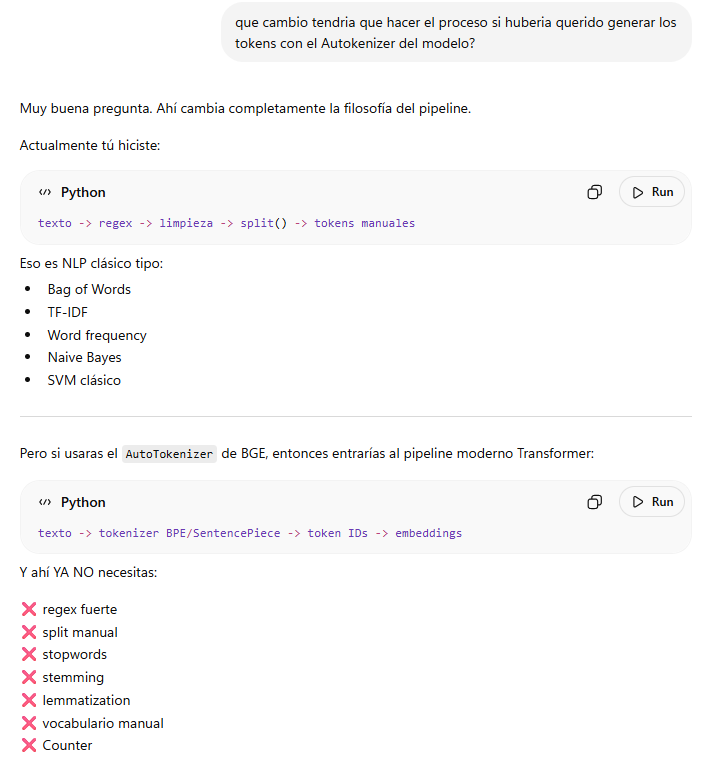

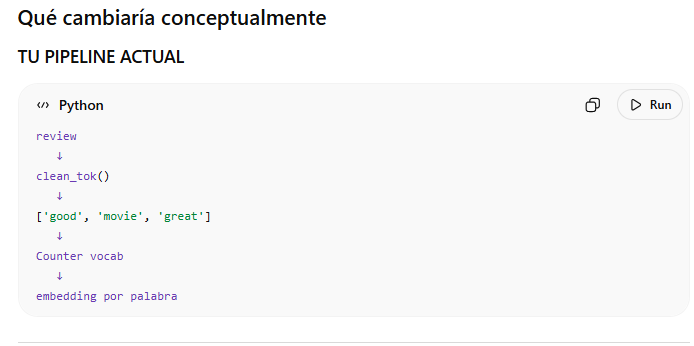

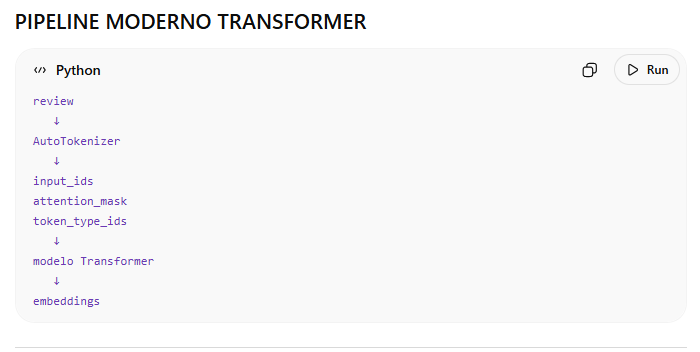

# **Pregunta - 9:**



Entrenamiento y reporte de los modelos de Regresión Logística y Bosque Aleatorio (Random Forest).


Utilizando los nuevos conjuntos embebidos de entrenamiento y validación del ejercicio anterior, realizar el entrneamiento con los modelos de regresión logística y bosque aleatorio (random forest). Para cada modelo muestra el valor de la exactitud (accuracy) y el reporte de sklearn dado por la función classification_report(). Verifica y justifica que no estén sobreentrenados ni subentrenados cada modelo. 

NOTA: Diremos que un modelo no está sobreentrenado, si la diferencia entre entrenamiento y validación es menor al 3%, con respecto a la métrica de exactitud. 

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

GRID SEARCH RESULTS

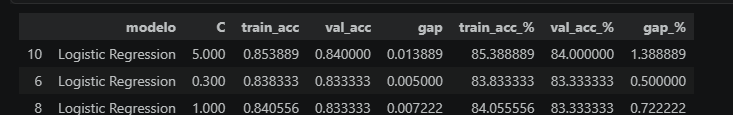

In [54]:
# 9a) REGRESIÓN LOGÍSTICA:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
modeloLRembeddings = LogisticRegression(
    random_state=1,
    max_iter=3000,
    C=5
)

modeloLRembeddings.fit(trainEmb, ytrain)

print('LR: Train-accuracy: %.2f%%' % (100*modeloLRembeddings.score(trainEmb, ytrain)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRembeddings.score(valEmb, yval)))
print()

y_pred_val_lr = modeloLRembeddings.predict(valEmb)
print(classification_report(yval, y_pred_val_lr))




# *********** Aquí termina la sección de agregar código *************


LR: Train-accuracy: 85.39%
LR: Val-accuracy: 84%

              precision    recall  f1-score   support

           0       0.83      0.85      0.84       300
           1       0.85      0.83      0.84       300

    accuracy                           0.84       600
   macro avg       0.84      0.84      0.84       600
weighted avg       0.84      0.84      0.84       600



GRID SEARCH RESULTS

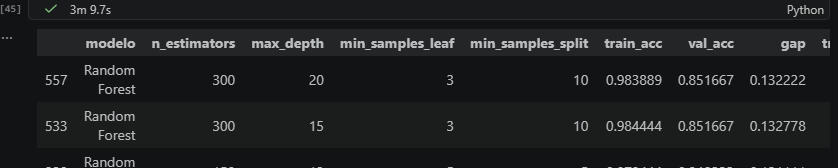

In [55]:
# 9b) BOSQUE ALEATORIO (Random Forest):

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Modelo Bosque Aleatorio (Random Forest):
modeloRFembeddings = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=1
)

modeloRFembeddings.fit(trainEmb, ytrain)

print('LR: Train-accuracy: %.2f%%' % (100*modeloRFembeddings.score(trainEmb, ytrain)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloRFembeddings.score(valEmb, yval)))
print()

y_pred_val_rf = modeloRFembeddings.predict(valEmb)
print(classification_report(yval, y_pred_val_rf))



# *********** Aquí termina la sección de agregar código *************

LR: Train-accuracy: 98.39%
LR: Val-accuracy: 85%

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       300
           1       0.86      0.84      0.85       300

    accuracy                           0.85       600
   macro avg       0.85      0.85      0.85       600
weighted avg       0.85      0.85      0.85       600



# **Pregunta - 10**

**Proceso basado en modelos Preentrenados**

10. Ahora, como segunda parte de esta actividad: 

a. Realiza la partición en Train-Val-Test con el mismo porcentaje, semilla y características 
utilizada en la primera parte de los 3000 comentarios tal como los obtuviste en la primer 
pregunta. Llamar a estos conjuntos X_train, X_val, X_test, y_train, y_val, y_test. Despliega la 
dimensión de dichos conjuntos. 

b. Realiza la transformación a vectores embebidos de cada uno de los conjuntos X_train, X_val, 
X_test. Selecciona el mismo modelo de vector embebido que utlizaste en la primera parte. 
Indica la cantidad de tokens utilizados para generar cada uno de estos tres conjuntos de 
entrenamiento, validación y prueba.

c. Utiliza los modelos de regresión logística y bosque aleatorio (random forest) para este 
problema de clasificación. Para cada modelo muestra el valor de la exactitud (accuracy) y el 
reporte de sklearn dado por la función classification_report(). Verifica que no estén sub o 
sobre entrenados y compara tus resultados con los que obtuviste en la primera parte. 

In [56]:
# 10a) Partición.:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# ************* Inicia la sección de agregar código:*****************************

from sklearn.model_selection import train_test_split

X_train, X_val_and_test, y_train, y_val_and_test = train_test_split(df.review, y, train_size=.60, shuffle=True, random_state=1,stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1,stratify=y_val_and_test)

print('X,y Train:', len(X_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(X_val), len(y_val))
print('X,y Test', len(X_test), len(y_test))
print()
print('\nTrain distribution:')
print(y_train.value_counts(normalize=True))
print()
print('\nValidation distribution:')
print(y_val.value_counts(normalize=True))
print()
print('\nTest distribution:')
print(y_test.value_counts(normalize=True))
print()



# *********** Termina la sección de agregar código *************


# verificemos las dimensiones obtenidas:
print('X,y Train:', len(X_train), len(y_train))
print('X,y Val:', len(X_val), len(y_val))
print('X,y Test', len(X_test), len(y_test))


# *********** Aquí termina la sección de agregar código *************

X,y Train: 1800 1800
X,y Val: 600 600
X,y Test 600 600


Train distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


Validation distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


Test distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

X,y Train: 1800 1800
X,y Val: 600 600
X,y Test 600 600


In [59]:
# 10b) Vectores embebidos:

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Train embeddings
trainEmb2 = model.encode(
    X_train.tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Validation embeddings
valEmb2 = model.encode(
    X_val.tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Test embeddings
testEmb2 = model.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)

# Dimensions
print(trainEmb2.shape)
print(valEmb2.shape)
print(testEmb2.shape)

# Auto-Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    "BAAI/bge-base-en-v1.5"
)

# Contar tokens
train_tokens = sum(
    len(tokenizer.tokenize(text))
    for text in X_train
)

val_tokens = sum(
    len(tokenizer.tokenize(text))
    for text in X_val
)

test_tokens = sum(
    len(tokenizer.tokenize(text))
    for text in X_test
)

print("Train tokens:", train_tokens)
print("Val tokens:", val_tokens)
print("Test tokens:", test_tokens)





# *********** Aquí termina la sección de agregar código *************

Batches:   0%|          | 0/57 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

(1800, 768)
(600, 768)
(600, 768)
Train tokens: 27124
Val tokens: 8917
Test tokens: 9164


In [60]:
# 10c) REGRESIÓN LOGÍSTICA.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********
# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
modeloLRembeddings2 = LogisticRegression(
    random_state=1,
    max_iter=3000,
    C=5
)

modeloLRembeddings2.fit(trainEmb2, y_train)

print('LR: Train-accuracy: %.2f%%' % (100*modeloLRembeddings2.score(trainEmb2, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRembeddings2.score(valEmb2, y_val)))
print()

y_pred_val_lr2 = modeloLRembeddings2.predict(valEmb2)
print(classification_report(y_val, y_pred_val_lr2))









# *********** Aquí termina la sección de agregar código *************

LR: Train-accuracy: 97.72%
LR: Val-accuracy: 96%

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       300
           1       0.95      0.97      0.96       300

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



In [61]:
# 10d) BOSQUE ALEATORIO.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********

# Modelo Bosque Aleatorio (Random Forest):
modeloRFembeddings2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=3,
    random_state=1
)

modeloRFembeddings2.fit(trainEmb2, y_train)

print('LR: Train-accuracy: %.2f%%' % (100*modeloRFembeddings2.score(trainEmb2, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloRFembeddings2.score(valEmb2, y_val)))
print()

y_pred_val_rf2 = modeloRFembeddings2.predict(valEmb2)
print(classification_report(y_val, y_pred_val_rf2))



# *********** Aquí termina la sección de agregar código *************

LR: Train-accuracy: 99.33%
LR: Val-accuracy: 96%

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       300
           1       0.94      0.98      0.96       300

    accuracy                           0.95       600
   macro avg       0.96      0.96      0.95       600
weighted avg       0.96      0.95      0.95       600



# **Pregunta - 11:**

Con el mejor modelo obtenido, utiliza el conjunto de prueba correspondiente para obtener la matriz de confusión y el classification_report() de sklearn. Incluye tus comentarios.

Logistic Regression generaliza mejor y tiene menos sobreentrenamiento.

Test Accuracy: 96.83%

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       300
           1       0.96      0.98      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

Confusion Matrix:
[[288  12]
 [  7 293]]


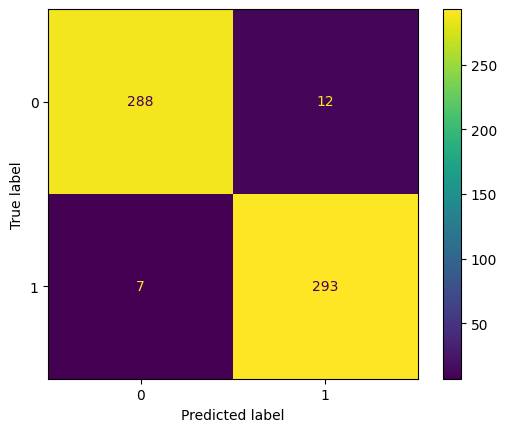

In [63]:
# Reporte del mejor modelo y partición con el conjunto de Prueba.

# ******* Inlcuye a continuación todas las líneas de código y celdas que requieras: ***********


# Predicciones sobre test
y_pred_test = modeloLRembeddings2.predict(testEmb2)

# Accuracy
print("Test Accuracy: %.2f%%" % (
    100 * modeloLRembeddings2.score(testEmb2, y_test)
))

print()

# Classification report
print(classification_report(y_test, y_pred_test))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)

# Visualizacion
ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()


# *********** Aquí termina la sección de agregar código *************

# **Pregunta - 12:**



Incluye tus comentarios finales de la actividad.

### ++++++++ Inicia la sección de agregar texto: +++++++++++

El mejor modelo obtenido fue la Regresión Logística utilizando embeddings directos generados con el modelo preentrenado `BAAI/bge-base-en-v1.5`.

El modelo logró una exactitud cercana al 96% tanto en validación como en prueba, manteniendo una diferencia pequeña respecto al conjunto de entrenamiento, lo cual indica buena capacidad de generalización y bajo sobreentrenamiento.

La matriz de confusión muestra que el modelo clasifica correctamente la mayoría de los comentarios positivos y negativos. Además, las métricas de precision, recall y f1-score se mantuvieron balanceadas entre ambas clases, indicando un desempeño consistente para el problema de análisis de sentimiento.

En comparación con el enfoque anterior basado en TF-IDF, el uso de embeddings preentrenados permitió capturar relaciones semánticas más profundas entre las palabras y los comentarios completos, produciendo una representación vectorial más rica y efectiva para la clasificación.

### ++++++++ Termina la sección de agregar texto: +++++++++++

# **Fin de la Actividad de Vectores Embebidos - HuggingFace**

# REFERENCE ONLY

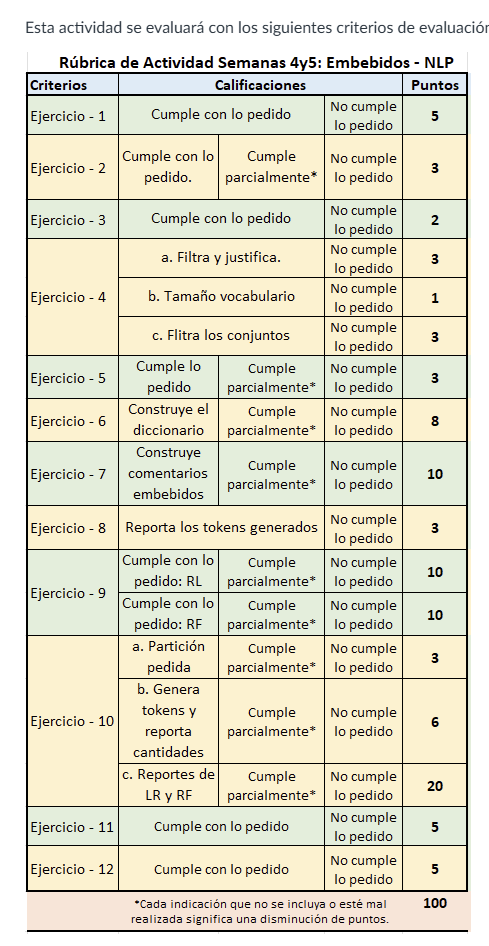

### Logistic regression GRID SEARCH

In [46]:
from sklearn.linear_model import LogisticRegression

resultados_lr = []

for C in [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.3, 0.5, 1, 2, 5]:
    
    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1
    )

    modelo.fit(trainEmb, ytrain)

    train_acc = modelo.score(trainEmb, ytrain)
    val_acc = modelo.score(valEmb, yval)
    gap = train_acc - val_acc

    resultados_lr.append({
        "modelo": "Logistic Regression",
        "C": C,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "gap": gap
    })

df_lr = pd.DataFrame(resultados_lr)
df_lr["train_acc_%"] = df_lr["train_acc"] * 100
df_lr["val_acc_%"] = df_lr["val_acc"] * 100
df_lr["gap_%"] = df_lr["gap"] * 100

df_lr.sort_values(by=["val_acc", "gap"], ascending=[False, True])

,modelo,C,train_acc,val_acc,gap,train_acc_%,val_acc_%,gap_%
10,Logistic Regression,5.000,0.853889,0.840000,0.013889,85.388889,84.000000,1.388889
6,Logistic Regression,0.300,0.838333,0.833333,0.005000,83.833333,83.333333,0.500000
8,Logistic Regression,1.000,0.840556,0.833333,0.007222,84.055556,83.333333,0.722222
9,Logistic Regression,2.000,0.845000,0.833333,0.011667,84.500000,83.333333,1.166667
5,Logistic Regression,0.100,0.835000,0.831667,0.003333,83.500000,83.166667,0.333333
1,Logistic Regression,0.005,0.834444,0.830000,0.004444,83.444444,83.000000,0.444444
2,Logistic Regression,0.010,0.834444,0.830000,0.004444,83.444444,83.000000,0.444444
3,Logistic Regression,0.020,0.834444,0.830000,0.004444,83.444444,83.000000,0.444444
7,Logistic Regression,0.500,0.837778,0.830000,0.007778,83.777778,83.000000,0.777778
0,Logistic Regression,0.001,0.833889,0.828333,0.005556,83.388889,82.833333,0.555556


### Random Forest GRID SEARCH

In [45]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

resultados_rf = []

for n_estimators in [100, 150, 200, 300]:
    for max_depth in [6, 8, 10, 12, 15, 20]:
        for min_samples_leaf in [2, 3, 4, 5, 6, 8]:
            for min_samples_split in [5, 10, 15, 20]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(trainEmb, ytrain)

                train_acc = modelo.score(trainEmb, ytrain)
                val_acc = modelo.score(valEmb, yval)
                gap = train_acc - val_acc

                resultados_rf.append({
                    "modelo": "Random Forest",
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "min_samples_split": min_samples_split,
                    "train_acc": train_acc,
                    "val_acc": val_acc,
                    "gap": gap
                })

df_rf = pd.DataFrame(resultados_rf)

df_rf["train_acc_%"] = df_rf["train_acc"] * 100
df_rf["val_acc_%"] = df_rf["val_acc"] * 100
df_rf["gap_%"] = df_rf["gap"] * 100

df_rf.sort_values(by=["val_acc", "gap"], ascending=[False, True]).head(10)

,modelo,n_estimators,max_depth,min_samples_leaf,min_samples_split,train_acc,val_acc,gap,train_acc_%,val_acc_%,gap_%
557,Random Forest,300,20,3,10,0.983889,0.851667,0.132222,98.388889,85.166667,13.222222
533,Random Forest,300,15,3,10,0.984444,0.851667,0.132778,98.444444,85.166667,13.277778
228,Random Forest,150,12,5,5,0.979444,0.848333,0.131111,97.944444,84.833333,13.111111
229,Random Forest,150,12,5,10,0.979444,0.848333,0.131111,97.944444,84.833333,13.111111
341,Random Forest,200,10,3,10,0.980000,0.848333,0.131667,98.000000,84.833333,13.166667
84,Random Forest,100,12,5,5,0.977778,0.846667,0.131111,97.777778,84.666667,13.111111
85,Random Forest,100,12,5,10,0.977778,0.846667,0.131111,97.777778,84.666667,13.111111
485,Random Forest,300,10,3,10,0.978333,0.846667,0.131667,97.833333,84.666667,13.166667
488,Random Forest,300,10,4,5,0.978889,0.846667,0.132222,97.888889,84.666667,13.222222
372,Random Forest,200,12,5,5,0.979444,0.846667,0.132778,97.944444,84.666667,13.277778
